# 🚗 Understanding Autonomous Vehicle Perception

Welcome! This notebook will teach you the fundamentals of how self-driving cars "see" the road.

**What you'll learn:**
1. How images are represented in computers
2. How neural networks detect objects
3. How lane lines are detected
4. How to combine everything into a system

## 📸 Part 1: How Computers See Images

Before we can detect cars and lanes, we need to understand how computers represent images.

In [10]:
# First, let's import our libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Make plots display inline
%matplotlib inline

print("Libraries loaded! ✅")

Libraries loaded! ✅


In [2]:
# An image is just a 3D array of numbers!
# Let's create a simple 10x10 image

# Create a red square
red_square = np.zeros((10, 10, 3), dtype=np.uint8)
red_square[:, :, 2] = 255  # Red channel (remember: OpenCV uses BGR, not RGB)

print("Image shape:", red_square.shape)
print("This means: 10 pixels tall, 10 pixels wide, 3 color channels (Blue, Green, Red)")
print("\nThe actual numbers (first 5x5 of red channel):")
print(red_square[:5, :5, 2])

Image shape: (10, 10, 3)
This means: 10 pixels tall, 10 pixels wide, 3 color channels (Blue, Green, Red)

The actual numbers (first 5x5 of red channel):
[[255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]]


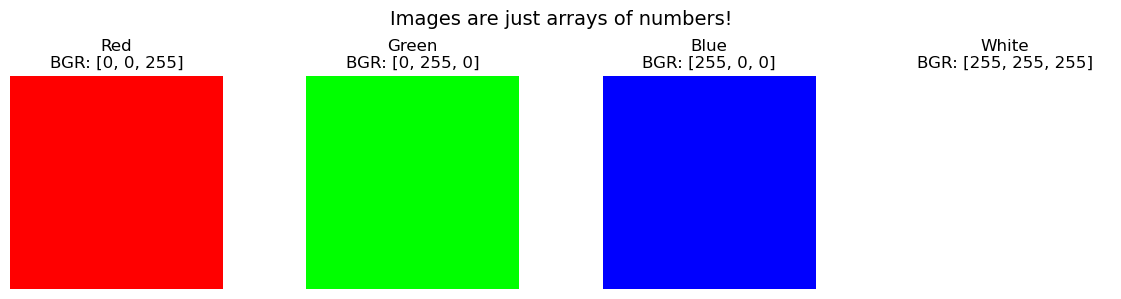

In [3]:
# Let's visualize some colors
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

colors = [
    ([0, 0, 255], 'Red'),
    ([0, 255, 0], 'Green'),
    ([255, 0, 0], 'Blue'),
    ([255, 255, 255], 'White')
]

for ax, (bgr, name) in zip(axes, colors):
    img = np.zeros((100, 100, 3), dtype=np.uint8)
    img[:] = bgr
    # Convert BGR to RGB for matplotlib
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{name}\nBGR: {bgr}')
    ax.axis('off')

plt.suptitle('Images are just arrays of numbers!', fontsize=14)
plt.tight_layout()
plt.show()

## 🎯 Part 2: Object Detection Basics

### What is Object Detection?

Object detection answers TWO questions:
1. **What** objects are in the image? (Classification)
2. **Where** are they? (Localization - bounding boxes)

### How YOLO Works (Simplified)

YOLO = "You Only Look Once"

Traditional methods scan the image multiple times. YOLO does it in ONE pass!

```
┌─────────────────────────────────────┐
│  Image divided into grid (e.g. 7x7)│
│  ┌───┬───┬───┬───┬───┬───┬───┐     │
│  │   │   │   │   │   │   │   │     │
│  ├───┼───┼───┼───┼───┼───┼───┤     │
│  │   │ 🚗│   │   │   │   │   │     │
│  ├───┼───┼───┼───┼───┼───┼───┤     │
│  │   │   │   │   │ 🚶│   │   │     │
│  └───┴───┴───┴───┴───┴───┴───┘     │
│                                     │
│  Each cell predicts:               │
│  - Is there an object here?        │
│  - What type?                      │
│  - Bounding box coordinates        │
└─────────────────────────────────────┘
```

In [4]:
# Let's simulate what YOLO outputs

# A detection has: [x1, y1, x2, y2, confidence, class_id]
# x1, y1 = top-left corner
# x2, y2 = bottom-right corner

example_detection = {
    'bbox': [100, 150, 300, 350],  # Box coordinates
    'confidence': 0.92,             # 92% sure it's correct
    'class_name': 'car',            # What type of object
    'class_id': 2                   # Numeric class ID
}

print("Example Detection:")
for key, value in example_detection.items():
    print(f"  {key}: {value}")

Example Detection:
  bbox: [100, 150, 300, 350]
  confidence: 0.92
  class_name: car
  class_id: 2


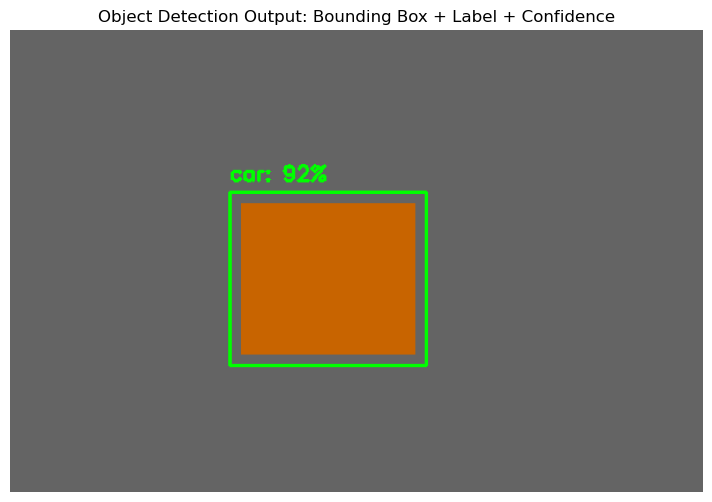

In [5]:
# Let's visualize a bounding box

# Create a simple "road" image
road_img = np.zeros((400, 600, 3), dtype=np.uint8)
road_img[:] = (100, 100, 100)  # Gray road

# Draw a "car" (just a rectangle for now)
cv2.rectangle(road_img, (200, 150), (350, 280), (0, 100, 200), -1)  # Brown-ish car

# Now draw the bounding box like YOLO would output
bbox = [190, 140, 360, 290]  # Slightly larger than the car
cv2.rectangle(road_img, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)

# Add label
cv2.putText(road_img, 'car: 92%', (bbox[0], bbox[1]-10), 
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(road_img, cv2.COLOR_BGR2RGB))
plt.title('Object Detection Output: Bounding Box + Label + Confidence')
plt.axis('off')
plt.show()

## 🛣️ Part 3: Lane Detection Basics

Lane detection finds the road boundaries. Here's the process:

1. **Focus on the road** (bottom half of image)
2. **Find lane colors** (white and yellow)
3. **Detect edges** (sharp changes in brightness)
4. **Find lines** (Hough Transform)
5. **Fit curves** (polynomial regression)

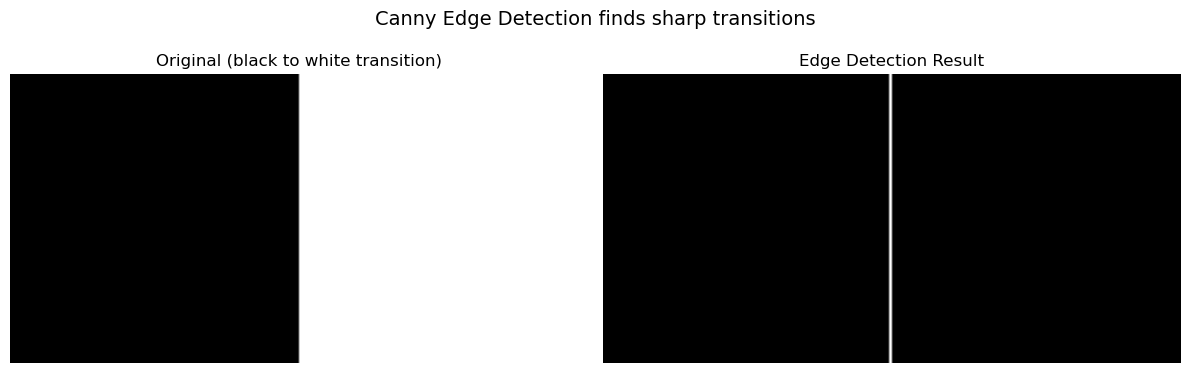

Edge detection finds where brightness changes suddenly - like lane markings on road!


In [6]:
# Let's understand edge detection - the key to finding lanes

# Create an image with a sharp edge
edge_demo = np.zeros((100, 200), dtype=np.uint8)
edge_demo[:, 100:] = 255  # Right half is white

# Apply Canny edge detection
edges = cv2.Canny(edge_demo, 50, 150)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(edge_demo, cmap='gray')
axes[0].set_title('Original (black to white transition)')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Edge Detection Result')

for ax in axes:
    ax.axis('off')

plt.suptitle('Canny Edge Detection finds sharp transitions', fontsize=14)
plt.tight_layout()
plt.show()

print("Edge detection finds where brightness changes suddenly - like lane markings on road!")

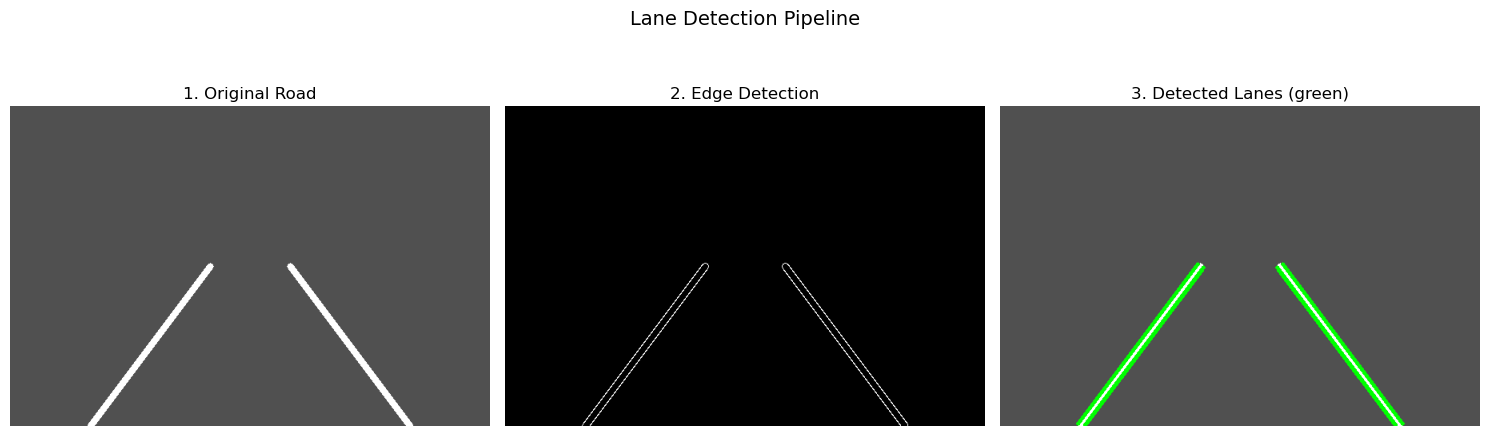

In [7]:
# Let's create a simple lane detection demo

# Create a road with lane lines
road = np.zeros((400, 600, 3), dtype=np.uint8)
road[:] = (80, 80, 80)  # Dark gray road

# Draw white lane lines
cv2.line(road, (100, 400), (250, 200), (255, 255, 255), 8)  # Left lane
cv2.line(road, (500, 400), (350, 200), (255, 255, 255), 8)  # Right lane

# Convert to grayscale
gray = cv2.cvtColor(road, cv2.COLOR_BGR2GRAY)

# Edge detection
edges = cv2.Canny(gray, 50, 150)

# Hough Line detection
lines = cv2.HoughLinesP(edges, 1, np.pi/180, 50, minLineLength=50, maxLineGap=10)

# Draw detected lines
result = road.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(result, (x1, y1), (x2, y2), (0, 255, 0), 3)

# Show results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(road, cv2.COLOR_BGR2RGB))
axes[0].set_title('1. Original Road')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('2. Edge Detection')

axes[2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[2].set_title('3. Detected Lanes (green)')

for ax in axes:
    ax.axis('off')

plt.suptitle('Lane Detection Pipeline', fontsize=14)
plt.tight_layout()
plt.show()

## 🔗 Part 4: Putting It All Together

Now you understand the basics! Here's how our full system works:

```
┌─────────────┐
│ Video Frame │
└──────┬──────┘
       │
       ▼
┌─────────────────────────────────────┐
│           PERCEPTION SYSTEM          │
│  ┌───────────────┐ ┌──────────────┐ │
│  │ YOLOv8        │ │ Lane Detect  │ │
│  │ (finds cars,  │ │ (finds road  │ │
│  │  people, etc) │ │  boundaries) │ │
│  └───────┬───────┘ └──────┬───────┘ │
│          │                │         │
│          ▼                ▼         │
│  ┌─────────────────────────────────┐│
│  │         Visualizer              ││
│  │  (draws boxes, lanes, metrics)  ││
│  └─────────────────────────────────┘│
└─────────────────────────────────────┘
       │
       ▼
┌─────────────────────────────────────┐
│  Annotated Frame + Performance      │
│  Metrics (FPS, accuracy, etc)       │
└─────────────────────────────────────┘
```

In [8]:
# Let's use our actual modules!
import sys
sys.path.append('../src')

try:
    from detector import ObjectDetector
    from lane_detector import LaneDetector
    from visualizer import Visualizer
    print("✅ Successfully imported our modules!")
except ImportError as e:
    print(f"Note: {e}")
    print("This is fine - we'll use the concepts we learned above.")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\ADEYEMI SODIQ\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Successfully imported our modules!


## 🎓 Key Takeaways

1. **Images are arrays** - Each pixel is just numbers (R, G, B values)

2. **Object Detection** - Neural networks learn to:
   - Classify: "This region looks like a car"
   - Localize: "The car is at these coordinates"

3. **Lane Detection** - Classical CV techniques:
   - Edge detection finds boundaries
   - Color filtering finds lane colors
   - Hough transform finds lines

4. **Real-time is hard** - Must process 25+ frames per second

## 📚 Next Steps

In the next notebook (`02_running_the_pipeline.ipynb`), we'll:
- Download sample driving footage
- Run our actual detection models
- Analyze the results

In [9]:
print("\n" + "="*50)
print("🎉 Congratulations! You understand the basics!")
print("="*50)
print("\nYou now know:")
print("  ✅ How computers represent images")
print("  ✅ How object detection works (YOLO)")
print("  ✅ How lane detection works")
print("  ✅ How they combine into a perception system")
print("\nNext: Run the actual system on real video!")


🎉 Congratulations! You understand the basics!

You now know:
  ✅ How computers represent images
  ✅ How object detection works (YOLO)
  ✅ How lane detection works
  ✅ How they combine into a perception system

Next: Run the actual system on real video!
